# Intra-case perspective — control-flow drift

Control-flow drift rewires the process model. It shows up as shifted **trace variants**, a changed **activity mix**, and rewired **directly-follows** relations. Drift points (crimson lines) are read from the log's `rheon:metadata`.

In [1]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
LOG = ROOT / "data" / "intra.xes"
PERSPECTIVE = "intra-case"
WINDOW_DAYS = 45
NS = "{http://www.xes-standard.org/}"


def read_metadata(path):
    """Pull the rheon:metadata JSON from the log header without parsing every trace."""
    for event, elem in ET.iterparse(str(path), events=("start", "end")):
        if event == "end" and elem.tag == f"{NS}string" and elem.attrib.get("key") == "rheon:metadata":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{NS}trace":
            break
    return {}


meta = read_metadata(LOG)
drifts = [d for d in meta.get("drifts", []) if d["perspective"] == PERSPECTIVE]
for d in drifts:
    d["date"] = pd.Timestamp(d.get("drift_point_date") or d["drift_start_date"])

pd.DataFrame([{"id": d["id"], "type": d["type"], "mode": d["mode"], "date": d["date"]}
             for d in drifts])

,id,type,mode,date
0,d01,control_flow,sudden,2020-05-26 00:00:00+00:00
1,d02,control_flow,sudden,2020-09-30 18:00:00+00:00


In [2]:
df = pm4py.read_xes(str(LOG)).rename(columns={
    "case:concept:name": "case", "concept:name": "activity",
    "start_timestamp": "start", "time:timestamp": "end",
    "org:resource": "resource", "event:duration_min": "duration",
    "case:amount": "amount", "case:region": "region",
})
df["start"] = pd.to_datetime(df["start"], utc=True)
df["end"] = pd.to_datetime(df["end"], utc=True)
df = df.sort_values(["case", "start"]).reset_index(drop=True)
df["week"] = df["end"].dt.to_period("W").dt.start_time
df["wait_min"] = ((df["start"] - df.groupby("case")["end"].shift()).dt.total_seconds() / 60).clip(lower=0)

cases = (df.groupby("case")
         .agg(start=("start", "min"), end=("end", "max"), length=("activity", "size"),
              variant=("activity", " ".join), amount=("amount", "first"), region=("region", "first"))
         .reset_index().sort_values("start").reset_index(drop=True))
cases["week"] = cases["start"].dt.to_period("W").dt.start_time
cases["gap_min"] = cases["start"].diff().dt.total_seconds() / 60

acts = sorted(df["activity"].unique())
ress = sorted(df["resource"].dropna().unique())
ACT = dict(zip(acts, map(to_hex, sns.color_palette("Set2", max(len(acts), 1)))))
RES = dict(zip(ress, map(to_hex, sns.color_palette("tab20", max(len(ress), 1)))))


def drift_lines(ax, subset=None):
    """Mark drift change points on a time axis."""
    for d in (drifts if subset is None else subset):
        ax.axvline(d["date"], color="crimson", ls="--", lw=1, alpha=0.8)
        ax.annotate(d["id"], (d["date"], 1), xycoords=("data", "axes fraction"),
                    ha="center", va="bottom", fontsize=8, color="crimson")


def window(d, by="event", days=WINDOW_DAYS):
    """Events (by='event') or cases (by='case') just before vs after a drift, clipped to neighbours."""
    t = d["date"]
    near = [x["date"] for x in drifts if x["date"] != t]
    lo = max([t - pd.Timedelta(days=days)] + [o for o in near if o < t])
    hi = min([t + pd.Timedelta(days=days)] + [o for o in near if o > t])
    if by == "case":
        return (cases[(cases["start"] >= lo) & (cases["start"] < t)],
                cases[(cases["start"] >= t) & (cases["start"] < hi)])
    return df[(df["end"] >= lo) & (df["end"] < t)], df[(df["end"] >= t) & (df["end"] < hi)]

/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


parsing log, completed traces ::   0%|          | 0/2464 [00:00<?, ?it/s]

parsing log, completed traces ::  65%|██████▌   | 1607/2464 [00:00<00:00, 11743.45it/s]

parsing log, completed traces :: 100%|██████████| 2464/2464 [00:00<00:00, 13839.79it/s]

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_64281/1234163824.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["end"].dt.to_period("W").dt.start_time
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_64281/1234163824.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cases["week"] = cases["start"].dt.to_period("W").dt.start_time


## Global overview

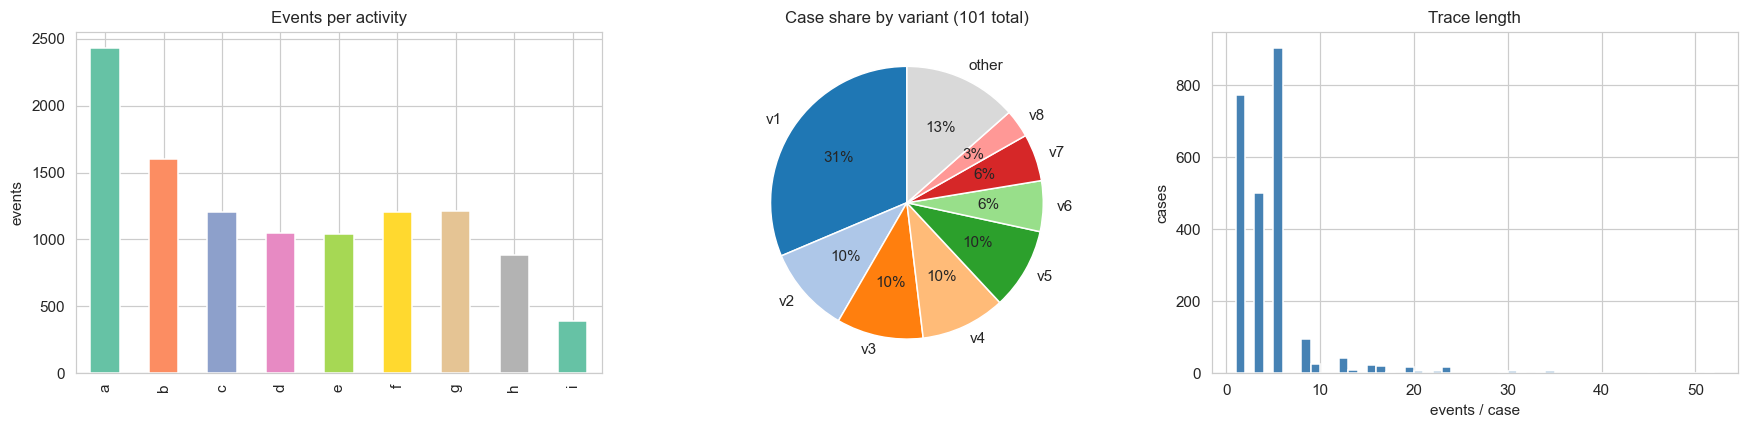

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

df["activity"].value_counts().reindex(acts).plot.bar(ax=ax[0], color=[ACT[a] for a in acts])
ax[0].set(title="Events per activity", xlabel="", ylabel="events")

vc = cases["variant"].value_counts()
top = vc.head(8)
ax[1].pie(list(top.values) + [vc.iloc[8:].sum()],
          labels=[f"v{i+1}" for i in range(len(top))] + ["other"], autopct="%1.0f%%",
          startangle=90, colors=sns.color_palette("tab20", len(top)) + [(.85, .85, .85)])
ax[1].set(title=f"Case share by variant ({cases['variant'].nunique()} total)")

ax[2].hist(cases["length"], bins=range(cases["length"].min(), cases["length"].max() + 2), color="steelblue")
ax[2].set(title="Trace length", xlabel="events / case", ylabel="cases")
plt.tight_layout(); plt.show()

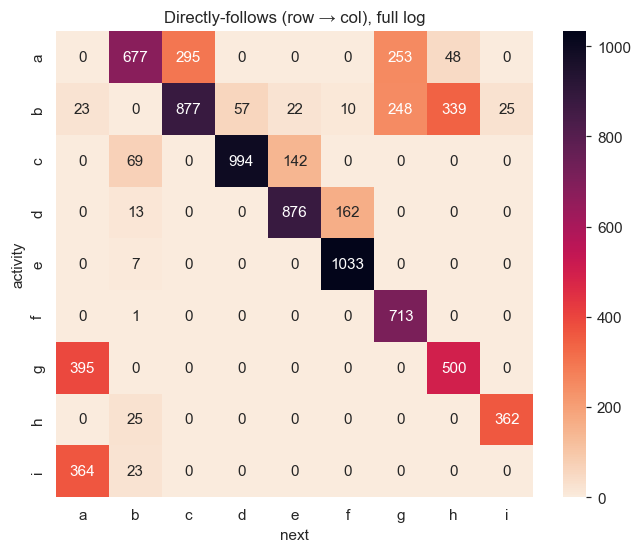

In [4]:
nxt = df.assign(nx=df.groupby("case")["activity"].shift(-1)).dropna(subset=["nx"])
dfg = pd.crosstab(nxt["activity"], nxt["nx"]).reindex(index=acts, columns=acts, fill_value=0)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(dfg, annot=True, fmt="d", cmap="rocket_r", ax=ax)
ax.set(title="Directly-follows (row \u2192 col), full log", xlabel="next", ylabel="activity")
plt.show()

## Over time

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_64281/1967994683.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  wk = wk[order].div(wk[order].sum(1), axis=0)


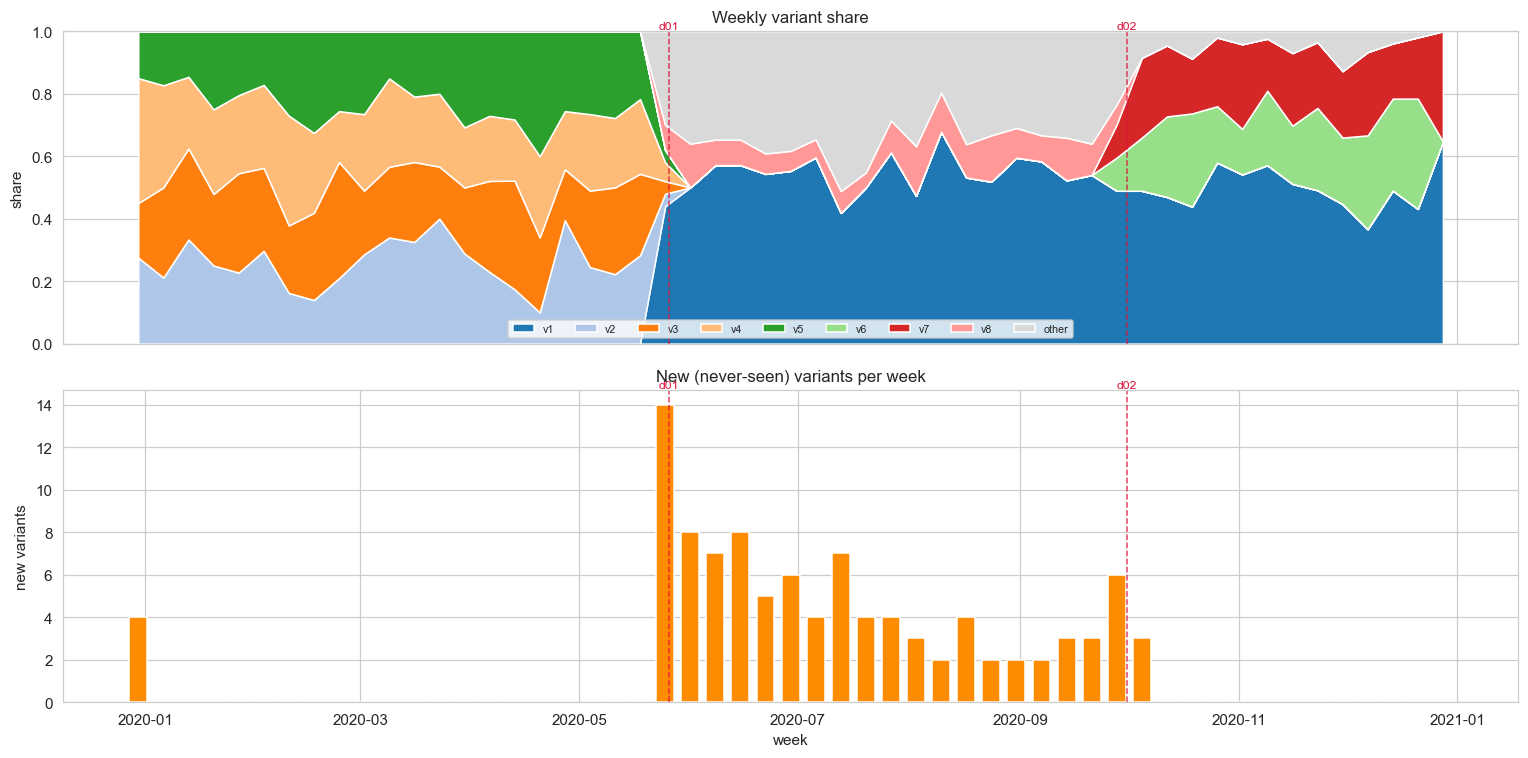

In [5]:
top_v = cases["variant"].value_counts().head(8).index
bucket = cases.assign(v=cases["variant"].where(cases["variant"].isin(top_v), "other"))
wk = bucket.groupby(["week", "v"]).size().unstack(fill_value=0)
order = list(top_v) + (["other"] if "other" in wk.columns else [])
wk = wk[order].div(wk[order].sum(1), axis=0)

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].stackplot(wk.index, wk.T.values,
                labels=[f"v{i+1}" for i in range(len(top_v))] + (["other"] if "other" in order else []),
                colors=sns.color_palette("tab20", len(top_v)) + [(.85, .85, .85)])
ax[0].set(title="Weekly variant share", ylabel="share", ylim=(0, 1))
ax[0].legend(ncol=9, fontsize=7, loc="lower center"); drift_lines(ax[0])

seen, new = set(), []
for w, g in cases.groupby("week"):
    v = set(g["variant"]); new.append((w, len(v - seen))); seen |= v
nv = pd.DataFrame(new, columns=["week", "n"]).set_index("week")
ax[1].bar(nv.index, nv["n"], width=5, color="darkorange")
ax[1].set(title="New (never-seen) variants per week", xlabel="week", ylabel="new variants")
drift_lines(ax[1])
plt.tight_layout(); plt.show()

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_64281/3898566540.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  wa = wa.div(wa.sum(1), axis=0)


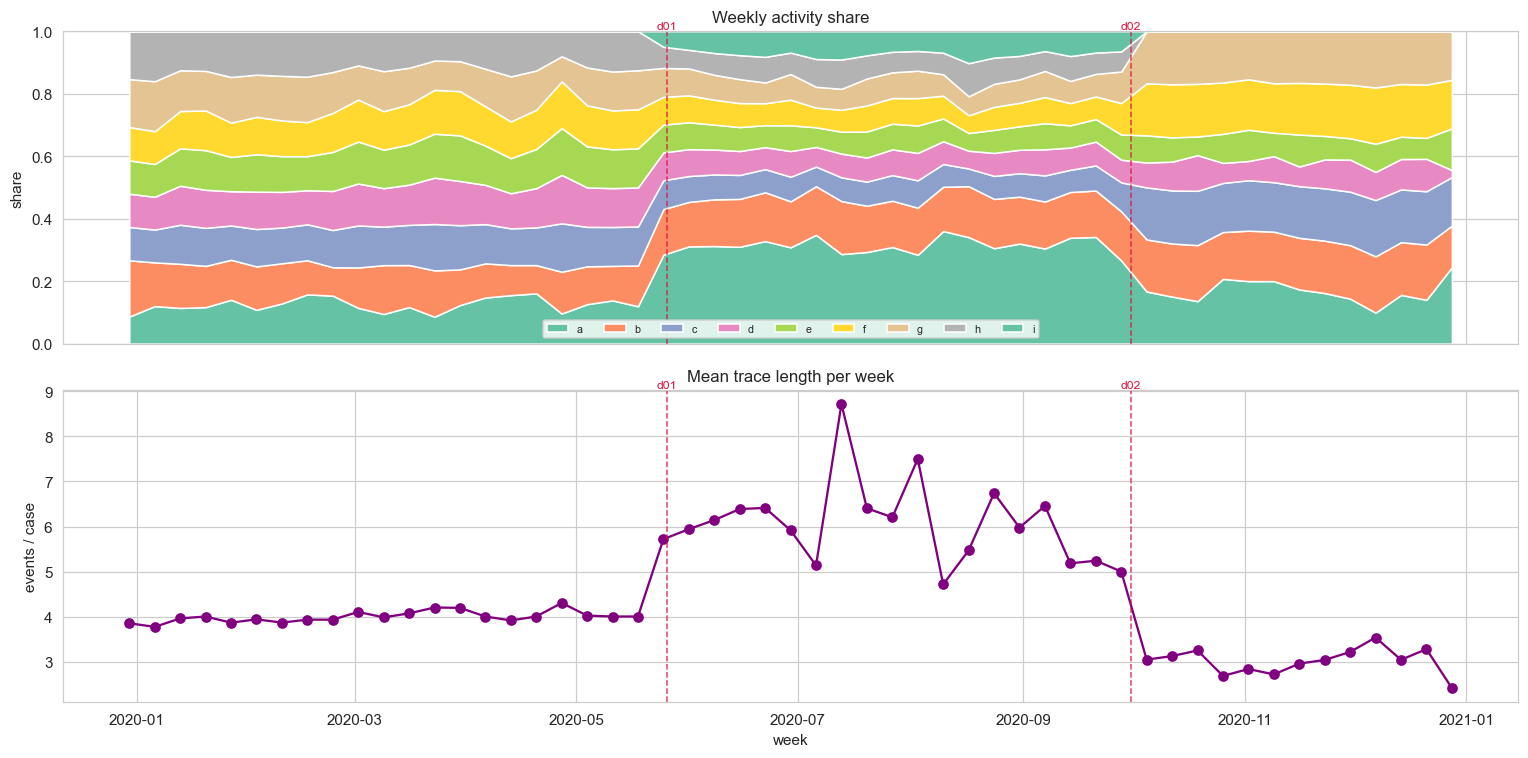

In [6]:
wa = df.groupby(["week", "activity"]).size().unstack(fill_value=0).reindex(columns=acts, fill_value=0)
wa = wa.div(wa.sum(1), axis=0)
ml = cases.groupby("week")["length"].mean()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].stackplot(wa.index, wa.T.values, labels=acts, colors=[ACT[a] for a in acts])
ax[0].set(title="Weekly activity share", ylabel="share", ylim=(0, 1))
ax[0].legend(ncol=len(acts), fontsize=7, loc="lower center"); drift_lines(ax[0])
ax[1].plot(ml.index, ml.values, marker="o", color="purple")
ax[1].set(title="Mean trace length per week", xlabel="week", ylabel="events / case"); drift_lines(ax[1])
plt.tight_layout(); plt.show()

## Before vs after each drift

Activity mix, top variants, and the directly-follows change in a window around each drift.

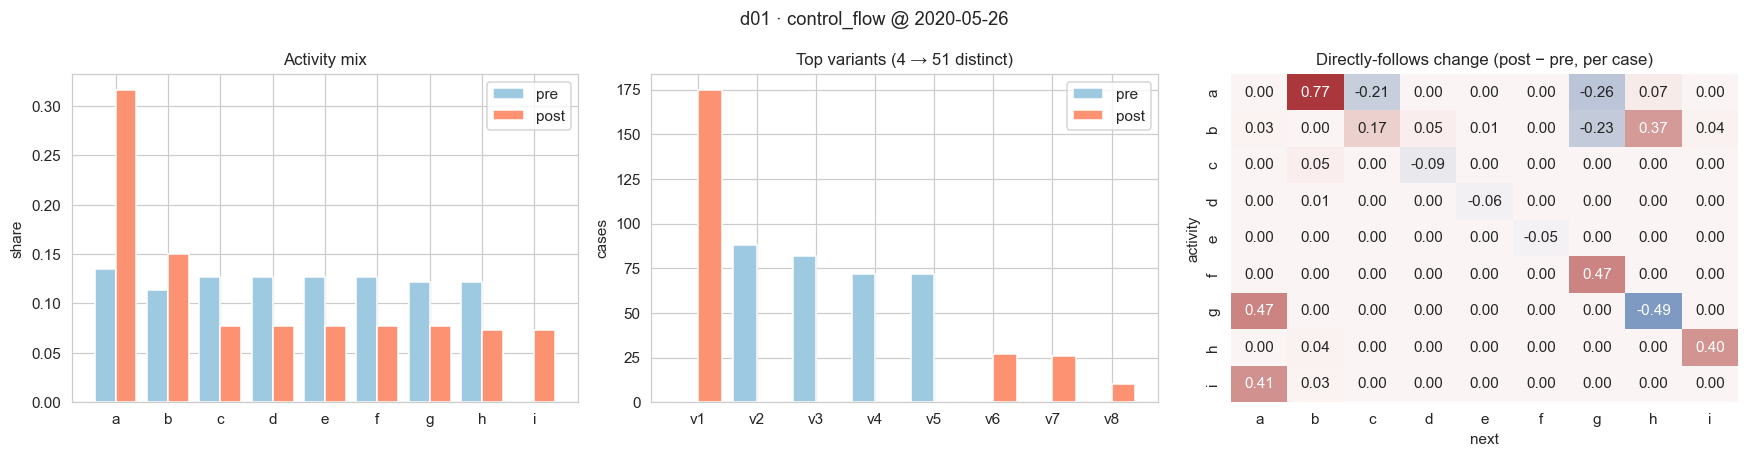

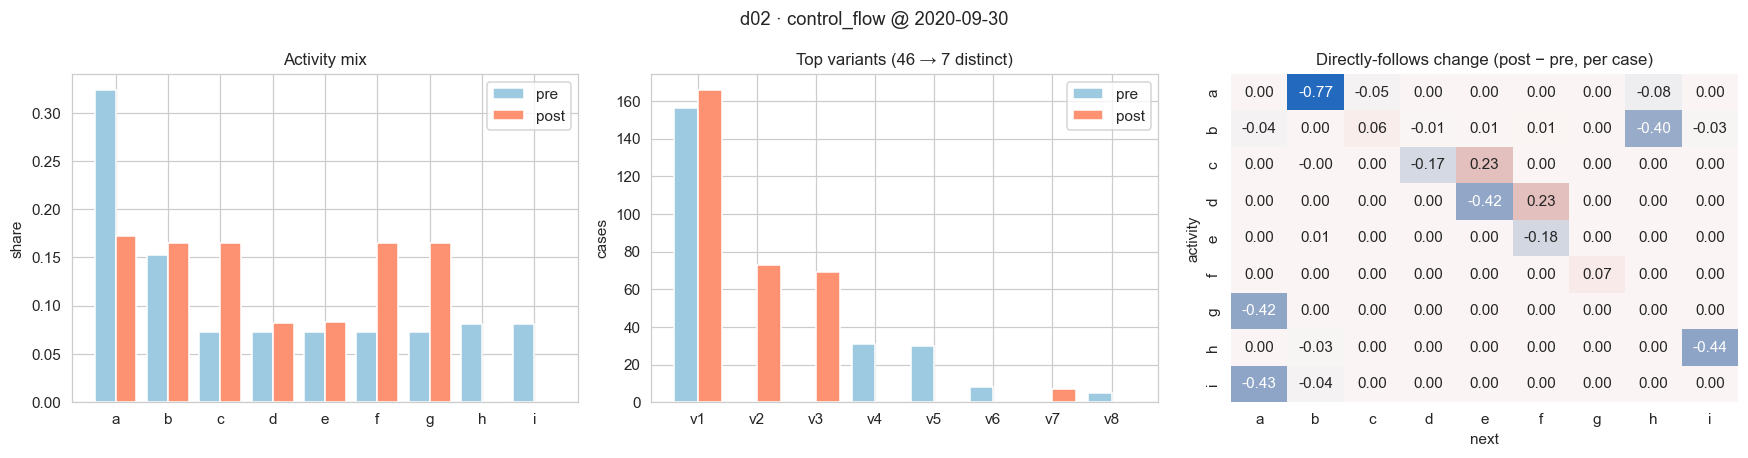

In [7]:
def dfg_norm(sub, n):
    nx = sub.assign(nx=sub.groupby("case")["activity"].shift(-1)).dropna(subset=["nx"])
    return pd.crosstab(nx["activity"], nx["nx"]).reindex(index=acts, columns=acts, fill_value=0) / max(n, 1)

for d in drifts:
    cpre, cpost = window(d, by="case")
    pre, post = df[df["case"].isin(cpre["case"])], df[df["case"].isin(cpost["case"])]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
    fig.suptitle(f"{d['id']} \u00b7 control_flow @ {d['date']:%Y-%m-%d}")

    x = np.arange(len(acts))
    ax[0].bar(x - 0.2, pre["activity"].value_counts(normalize=True).reindex(acts, fill_value=0).values, 0.4, label="pre", color="#9ecae1")
    ax[0].bar(x + 0.2, post["activity"].value_counts(normalize=True).reindex(acts, fill_value=0).values, 0.4, label="post", color="#fc9272")
    ax[0].set_xticks(x); ax[0].set_xticklabels(acts); ax[0].set(title="Activity mix", ylabel="share"); ax[0].legend()

    vt = pd.concat([cpre, cpost])["variant"].value_counts().head(8).index
    xv = np.arange(len(vt))
    ax[1].bar(xv - 0.2, cpre["variant"].value_counts().reindex(vt, fill_value=0).values, 0.4, label="pre", color="#9ecae1")
    ax[1].bar(xv + 0.2, cpost["variant"].value_counts().reindex(vt, fill_value=0).values, 0.4, label="post", color="#fc9272")
    ax[1].set_xticks(xv); ax[1].set_xticklabels([f"v{i+1}" for i in range(len(vt))])
    ax[1].set(title=f"Top variants ({cpre['variant'].nunique()} \u2192 {cpost['variant'].nunique()} distinct)", ylabel="cases"); ax[1].legend()

    sns.heatmap(dfg_norm(post, len(cpost)) - dfg_norm(pre, len(cpre)), annot=True, fmt=".2f",
                cmap="vlag", center=0, ax=ax[2], cbar=False)
    ax[2].set(title="Directly-follows change (post \u2212 pre, per case)", xlabel="next", ylabel="activity")
    plt.tight_layout(); plt.show()